In [144]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import recall_score, make_scorer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, KNNImputer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from xgboost import plot_importance
from xgboost import plot_importance
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve, auc, balanced_accuracy_score
from sklearn.utils.class_weight import compute_sample_weight




## Load Dataset

In [145]:
data = pd.read_csv(
    'T49.2_Sep2025_1_StGallen.csv',
    sep=';',
    na_values=["", " ", "NA", "N/A", "NULL"]
)

# commas instead of dots
data = data.replace(",", ".", regex=True)

# Nur Spalten numerisch machen, die wirklich vollständig numerisch sind
for col in data.columns:
    # Wenn alle Werte numerisch interpretierbar sind, dann konvertieren
    temp = pd.to_numeric(data[col], errors="coerce")
    if temp.notna().sum() == len(data[col]):   # ALLE Werte numerisch
        data[col] = temp

# Alles, was wie eine Zahl aussieht, in echte Zahlen umwandeln
data = data.apply(pd.to_numeric, errors='ignore')
display(data)

# Zielvariable abtrennen
X = data.drop("OUTCOME_3Kat_KHK", axis=1)
y = data["OUTCOME_3Kat_KHK"] 

/var/folders/m3/k3b3svlj7tvdqbtttg5w9xfw0000gn/T/ipykernel_9014/3653436355.py:1: DtypeWarning: Columns (3,32,119,121,125,129,231,330,342,588) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(
/var/folders/m3/k3b3svlj7tvdqbtttg5w9xfw0000gn/T/ipykernel_9014/3653436355.py:18: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  data = data.apply(pd.to_numeric, errors='ignore')


,OUTCOME_3Kat_KHK,Alter_0,geschlecht,waist_0,WHR_0,BMI_0,currsmo0,RR_syst_0,RR_diast_0,Pulse_Pressure,...,SMC231l,SMC232l,SMC233l,SMC240l,SMC241l,SMC242l,SMC243l,SMC244l,SMC263l,SMC264l
0,2,56.969199,0,112.0,0.982456,32.873110,0,130.0,80.0,50.0,...,9.44,4.38,3.99,14.1,25.8,7.8,3.99,3.99,3.99,3.99
1,2,69.497604,0,104.0,1.040000,30.110279,0,160.0,70.0,90.0,...,19.80,8.97,7.75,21.9,41.3,20.1,7.35,NaN,7.45,8.11
2,2,72.049281,0,129.0,0.941606,44.734880,0,140.0,90.0,50.0,...,13.90,4.75,3.99,20.3,52.4,18.6,3.99,3.99,3.99,3.99
3,2,70.814511,0,99.0,0.876106,26.259585,0,130.0,90.0,40.0,...,20.00,8.73,7.85,25.3,50.7,17.0,0.00,NaN,7.63,9.02
4,2,62.160164,1,125.0,NaN,42.436634,1,180.0,100.0,80.0,...,16.90,9.14,8.30,29.5,43.0,17.9,8.13,0.00,8.40,8.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2305,0,48.000000,1,94.0,NaN,21.229050,0,115.0,64.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2306,0,68.000000,0,97.0,NaN,28.734694,0,222.0,101.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2307,0,66.220397,0,101.0,0.943925,26.573129,0,135.0,80.0,55.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2308,0,65.429158,0,93.0,0.930000,26.769780,0,140.0,80.0,60.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Preprocessing

In [146]:
# Drop Dependent Variables
columns_to_drop = [
    "remnantCholesterol0_corr", "ldl0_mmol", "hdl0_mmol",
    "triglyc0_mmol", "cholest0_mmol", "LDL_0_apo_B_ratio", "BONE_KAT"
]
data = data.drop(columns_to_drop, axis=1)

# Manuelle kategoriale Variablen definieren
manual_categorical_candidates = [
    "geschlecht",
    "currsmo0",
    "diabetes_ADA_final_0",
    "ANY_OPE",
    "ANY_OPO",
    "Osteoporos_inkl_Osteopenie_T_Wert_abhängig",
    "Osteoporose_T_Wert_abhängig"
]

# In data casten (damit Data Wrangler es sieht)
for col in manual_categorical_candidates:
    if col in data.columns:
        data[col] = data[col].astype(str)

# X/y definieren
X = data.drop("OUTCOME_3Kat_KHK", axis=1)
y = data["OUTCOME_3Kat_KHK"]

# Neue automatische Erkennung der Kategorien
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

# Numerische Features
numerical_features = X.select_dtypes(include=["float64", "int64"]).columns.tolist()
numerical_features = [
    col for col in numerical_features
    if col not in categorical_features
]

print("Kategoriale Features:", len(categorical_features))
print("Numerische Features:", len(numerical_features))

# Remove features with high missing values
missing_threshold = 1 # Changed from 0.8 to be more conservative
missing_ratios = X.isnull().sum() / len(X)
high_missing = missing_ratios[missing_ratios > missing_threshold].index.tolist()
print(f"Features with >{missing_threshold*100}% missing: {len(high_missing)}")
if len(high_missing) > 0:
    X = X.drop(columns=high_missing, errors='ignore')
    numerical_features = [f for f in numerical_features if f not in high_missing]
    categorical_features = [f for f in categorical_features if f not in high_missing]

# Remove highly correlated numerical features
if len(numerical_features) > 0:
    X_num = X[numerical_features].select_dtypes(include=['float64', 'int64'])
    if len(X_num.columns) > 0:
        corr_matrix = X_num.corr().abs()
        upper_triangle = corr_matrix.where(
            np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
        )
        to_remove = set()
        for column in upper_triangle.columns:
            high_corr = upper_triangle.index[upper_triangle[column] > 0.95].tolist()
            if high_corr:
                for col in high_corr:
                    if column not in to_remove:
                        to_remove.add(col)
        
        if len(to_remove) > 0:
            print(f"Removing {len(to_remove)} highly correlated features")
            X = X.drop(columns=list(to_remove), errors='ignore')
            numerical_features = [f for f in numerical_features if f not in to_remove]

print(f"After cleaning - Numerische Features: {len(numerical_features)}")
print(f"After cleaning - Kategoriale Features: {len(categorical_features)}")

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# weights
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

# Preprocessing Pipelines
# Impute categorical features
cat_pre = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

# Impute numerical features (use median to be robust to outliers)
num_pre = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", cat_pre, categorical_features),
        ("num", num_pre, numerical_features)  # Now imputes instead of passthrough
    ]
)

display(data)




Kategoriale Features: 7
Numerische Features: 634
Features with >100% missing: 0
Removing 428 highly correlated features
After cleaning - Numerische Features: 206
After cleaning - Kategoriale Features: 7


,OUTCOME_3Kat_KHK,Alter_0,geschlecht,waist_0,WHR_0,BMI_0,currsmo0,RR_syst_0,RR_diast_0,Pulse_Pressure,...,SMC231l,SMC232l,SMC233l,SMC240l,SMC241l,SMC242l,SMC243l,SMC244l,SMC263l,SMC264l
0,2,56.969199,0,112.0,0.982456,32.873110,0,130.0,80.0,50.0,...,9.44,4.38,3.99,14.1,25.8,7.8,3.99,3.99,3.99,3.99
1,2,69.497604,0,104.0,1.040000,30.110279,0,160.0,70.0,90.0,...,19.80,8.97,7.75,21.9,41.3,20.1,7.35,NaN,7.45,8.11
2,2,72.049281,0,129.0,0.941606,44.734880,0,140.0,90.0,50.0,...,13.90,4.75,3.99,20.3,52.4,18.6,3.99,3.99,3.99,3.99
3,2,70.814511,0,99.0,0.876106,26.259585,0,130.0,90.0,40.0,...,20.00,8.73,7.85,25.3,50.7,17.0,0.00,NaN,7.63,9.02
4,2,62.160164,1,125.0,NaN,42.436634,1,180.0,100.0,80.0,...,16.90,9.14,8.30,29.5,43.0,17.9,8.13,0.00,8.40,8.51
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2305,0,48.000000,1,94.0,NaN,21.229050,0,115.0,64.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2306,0,68.000000,0,97.0,NaN,28.734694,0,222.0,101.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2307,0,66.220397,0,101.0,0.943925,26.573129,0,135.0,80.0,55.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2308,0,65.429158,0,93.0,0.930000,26.769780,0,140.0,80.0,60.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Build Pipeline

## Improved Preprocessing: Intelligent Imputation for MAR (Missing at Random)

**Bei Missing at Random (MAR):**
- Fehlende Werte sind **nicht informativ** für die Zielvariable
- Imputation ist sinnvoll, da NaN keine kausale Bedeutung hat
- **Aber:** Intelligente Imputation statt einfacher Median/Mode

**Strategie:**
- **IterativeImputer**: Nutzt andere Features für bessere Imputation
- **KNNImputer**: Nutzt ähnliche Samples (Fallback)
- **Median**: Robustes Fallback


In [147]:
# IMPROVED PREPROCESSING für MAR (Missing at Random): Intelligente Imputation
# Bei MAR sind fehlende Werte nicht informativ → Imputation ist sinnvoll
# Aber: Intelligente Imputation statt einfacher Median/Mode
# Imports sind bereits in Cell 0 vorhanden

# Kategorische Features: Most Frequent Imputation (für OneHotEncoder)
cat_pre_improved = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),  # Für OneHotEncoder
    ("ohe", OneHotEncoder(handle_unknown="ignore"))
])

# Numerische Features: INTELLIGENTE Imputation statt einfacher Median
# Option 1: IterativeImputer (nutzt andere Features für Imputation)
# Option 2: KNNImputer (nutzt ähnliche Samples)
# Option 3: Median (robust, aber weniger intelligent)

# WICHTIG: Bei MAR sollten wir imputieren, aber intelligent!
# IterativeImputer nutzt andere Features für bessere Imputation
try:
    # Versuche IterativeImputer (besser für MAR)
    num_pre_improved = Pipeline(steps=[
        ("imputer", IterativeImputer(
            random_state=42,
            max_iter=10,
            imputation_order='ascending'  # Beginnt mit Features mit wenig NaN
        ))
    ])
    imputation_method = "IterativeImputer (nutzt andere Features)"
except:
    # Fallback: KNNImputer
    try:
        num_pre_improved = Pipeline(steps=[
            ("imputer", KNNImputer(n_neighbors=5))
        ])
        imputation_method = "KNNImputer (nutzt ähnliche Samples)"
    except:
        # Fallback: Median (robust)
        num_pre_improved = Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median"))
        ])
        imputation_method = "Median (robust fallback)"

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", cat_pre_improved, categorical_features),
        ("num", num_pre_improved, numerical_features)  # Intelligente Imputation für MAR
    ],
    remainder="passthrough"
)

print("✅ IMPROVED PREPROCESSING für MAR (Missing at Random):")
print(f"   - Numerische Features: {imputation_method}")
print("   - Kategorische Features: Most Frequent Imputation")
print("   - Bei MAR sind fehlende Werte nicht informativ → Imputation ist sinnvoll")
print("   - Intelligente Imputation nutzt andere Features/Samples für bessere Werte")
print("   - Weniger Verfälschung durch intelligentere Imputation!")


✅ IMPROVED PREPROCESSING für MAR (Missing at Random):
   - Numerische Features: IterativeImputer (nutzt andere Features)
   - Kategorische Features: Most Frequent Imputation
   - Bei MAR sind fehlende Werte nicht informativ → Imputation ist sinnvoll
   - Intelligente Imputation nutzt andere Features/Samples für bessere Werte
   - Weniger Verfälschung durch intelligentere Imputation!


In [148]:
# Set random seeds for reproducibility
np.random.seed(42)

# IMPROVED MODEL: Balanced regularization + more capacity + early stopping + SMOTE
# Feature selection INSIDE pipeline to prevent data leakage

# Fit preprocessor on training set
temp_preprocessor = preprocessor.fit(X_train, y_train)
X_train_transformed = temp_preprocessor.transform(X_train)
X_test_transformed = temp_preprocessor.transform(X_test)

# Convert sparse to dense (XGBoost handles dense arrays better)
from scipy.sparse import issparse
if issparse(X_train_transformed):
    X_train_transformed = X_train_transformed.toarray()
if issparse(X_test_transformed):
    X_test_transformed = X_test_transformed.toarray()

# Check class distribution
class_counts = pd.Series(y_train).value_counts().sort_index()
print(f"Class distribution:")
for cls, count in class_counts.items():
    class_name = {0: "No Stenosis", 1: "Non-significant stenosis", 2: "Significant Stenosis"}.get(cls, f"Class {cls}")
    pct = count / len(y_train) * 100
    print(f"  {class_name} (Class {cls}): {count} samples ({pct:.1f}%)")

print(f"\n🛡️ AGGRESSIVE ANTI-OVERFITTING:")
print(f"  1. REMOVED SMOTE (was causing overfitting)")
print(f"  2. Using class weights (more stable)")
print(f"  3. Features: 100 → 75 (reduced complexity)")
print(f"  4. Strong regularization: reg_lambda 2.5 → 4.0, reg_alpha 1.5 → 2.5")
print(f"  5. Reduced capacity: max_depth 3 → 2, n_estimators 200 → 150")
print(f"  6. Slower learning: learning_rate 0.05 → 0.03")
print(f"  7. More conservative: min_child_weight 4 → 6")
print(f"  8. More randomness: subsample 0.8 → 0.7, colsample_bytree 0.7 → 0.6")
print(f"  9. Aggressive early stopping: 20 → 10 rounds")

# AGGRESSIVE ANTI-OVERFITTING: Remove SMOTE, use class weights, strong regularization
from sklearn.pipeline import Pipeline as SklearnPipeline
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Calculate class weights to favor Significant Stenosis (class 2)
total_samples = len(y_train)
class_weights = {}
for cls in class_counts.index:
    class_weights[cls] = total_samples / (len(class_counts) * class_counts[cls])

# Increase weight for class 2 (Significant Stenosis) - multiply by 1.3x
class_weights[2] = class_weights[2] * 1.3
print(f"\nClass weights: {class_weights}")

# Create sample weights
sample_weights = np.array([class_weights[y] for y in y_train])

# AGGRESSIVE ANTI-OVERFITTING Pipeline: NO SMOTE + class weights + strong regularization
pipeline = SklearnPipeline([
    ("feature_selection", SelectKBest(mutual_info_classif, k=75)),  # Fewer features
    ("classifier", XGBClassifier(
        tree_method="hist",
        n_estimators=150,  # Fewer trees
        learning_rate=0.03,  # Slower learning
        max_depth=2,  # Shallow trees
        min_child_weight=6,  # More conservative
        subsample=0.7,  # More randomness
        colsample_bytree=0.6,  # More randomness
        reg_lambda=4.0,  # Strong L2 regularization
        reg_alpha=2.5,  # Strong L1 regularization
        random_state=42,
        eval_metric="mlogloss",
        n_jobs=-1,
        objective="multi:softprob", 
        num_class=3
    )),
])

# CV and training - feature selection happens INSIDE CV (no data leakage)
# IMPROVED: Use early stopping in CV for better generalization
# Convert y_train to numpy array to avoid pandas indexing issues
y_train_array = np.array(y_train) if isinstance(y_train, pd.Series) else y_train
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores_list = []

for train_idx, val_idx in cv_strategy.split(X_train_transformed, y_train_array):
    X_train_cv, X_val_cv = X_train_transformed[train_idx], X_train_transformed[val_idx]
    y_train_cv, y_val_cv = y_train_array[train_idx], y_train_array[val_idx]
    sample_weights_cv = sample_weights[train_idx]
    
    # AGGRESSIVE ANTI-OVERFITTING: Transform validation data through feature selection BEFORE eval_set
    feature_selector = SelectKBest(mutual_info_classif, k=75)
    X_train_cv_selected = feature_selector.fit_transform(X_train_cv, y_train_cv)
    X_val_cv_selected = feature_selector.transform(X_val_cv)
    
    # AGGRESSIVE ANTI-OVERFITTING: NO SMOTE - use class weights instead
    classifier_cv = XGBClassifier(
        tree_method="hist",
        n_estimators=150,
        learning_rate=0.03,
        max_depth=2,
        min_child_weight=6,
        subsample=0.7,
        colsample_bytree=0.6,
        reg_lambda=4.0,
        reg_alpha=2.5,
        random_state=42,
        eval_metric="mlogloss",
        n_jobs=-1,
        objective="multi:softprob", 
        num_class=3,
        early_stopping_rounds=10  # Aggressive early stopping
    )
    
    classifier_cv.fit(X_train_cv_selected, y_train_cv,
                     sample_weight=sample_weights_cv,
                     eval_set=[(X_val_cv_selected, y_val_cv)],
                     verbose=False)
    
    # Evaluate on CV validation fold
    y_pred_cv = classifier_cv.predict(X_val_cv_selected)
    cv_score = balanced_accuracy_score(y_val_cv, y_pred_cv)
    cv_scores_list.append(cv_score)

cv_scores = np.array(cv_scores_list)
print(f"\nCross-validation scores: {cv_scores}")
print(f"Mean CV Balanced Accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

# FIXED: Fit final model with early stopping on validation set
# Split training data for early stopping
from sklearn.model_selection import train_test_split
X_train_fit, X_train_val, y_train_fit, y_train_val = train_test_split(
    X_train_transformed, y_train_array, test_size=0.15, random_state=42, stratify=y_train_array
)

print(f"\nFitting final model with early stopping...")
# AGGRESSIVE ANTI-OVERFITTING: Transform validation data through pipeline steps BEFORE eval_set
# Fit feature selection first
feature_selector = SelectKBest(mutual_info_classif, k=75)
X_train_fit_selected = feature_selector.fit_transform(X_train_fit, y_train_fit)
X_train_val_selected = feature_selector.transform(X_train_val)

# Get sample weights for training set
sample_weights_fit = np.array([class_weights[y] for y in y_train_fit])

# AGGRESSIVE ANTI-OVERFITTING: NO SMOTE - use class weights instead
classifier = XGBClassifier(
    tree_method="hist",
    n_estimators=200,
    learning_rate=0.03,
    max_depth=2,
    min_child_weight=6,
    subsample=0.7,
    colsample_bytree=0.6,
    reg_lambda=4.0,
    reg_alpha=2.5,
    random_state=42,
    eval_metric="mlogloss",
    n_jobs=-1,
    objective="multi:softprob", 
    num_class=3,
    early_stopping_rounds=10  # Aggressive early stopping
)

classifier.fit(X_train_fit_selected, y_train_fit,
              sample_weight=sample_weights_fit,
              eval_set=[(X_train_val_selected, y_train_val)],
              verbose=False)

# Reconstruct pipeline for consistency (for prediction later)
pipeline = SklearnPipeline([
    ("feature_selection", feature_selector),
    ("classifier", classifier)
])

# Get selected features from fitted pipeline
selected_features_mask = pipeline.named_steps['feature_selection'].get_support()
X_train_selected = X_train_transformed[:, selected_features_mask]
X_test_selected = X_test_transformed[:, selected_features_mask]

print(f"Selected {X_train_selected.shape[1]} features out of {X_train_transformed.shape[1]}")

# Predict on the test set
y_pred = pipeline.predict(X_test_transformed)
y_proba = pipeline.predict_proba(X_test_transformed)

Class distribution:
  No Stenosis (Class 0): 285 samples (15.4%)
  Non-significant stenosis (Class 1): 504 samples (27.3%)
  Significant Stenosis (Class 2): 1059 samples (57.3%)

🛡️ AGGRESSIVE ANTI-OVERFITTING:
  1. REMOVED SMOTE (was causing overfitting)
  2. Using class weights (more stable)
  3. Features: 100 → 75 (reduced complexity)
  4. Strong regularization: reg_lambda 2.5 → 4.0, reg_alpha 1.5 → 2.5
  5. Reduced capacity: max_depth 3 → 2, n_estimators 200 → 150
  6. Slower learning: learning_rate 0.05 → 0.03
  7. More conservative: min_child_weight 4 → 6
  8. More randomness: subsample 0.8 → 0.7, colsample_bytree 0.7 → 0.6
  9. Aggressive early stopping: 20 → 10 rounds

Class weights: {0: np.float64(2.16140350877193), 1: np.float64(1.2222222222222223), 2: np.float64(0.7561850802644005)}

Cross-validation scores: [0.49691489 0.49163037 0.5302746  0.43972195 0.4907023 ]
Mean CV Balanced Accuracy: 0.4898 (+/- 0.0580)

Fitting final model with early stopping...
Selected 75 features 

# Randomized Search

In [76]:

from sklearn.model_selection import RandomizedSearchCV

# Define parameter distributions
param_dist = {
'classifier__learning_rate': [0.02, 0.03, 0.04, 0.05],
'classifier__max_depth': [5, 6, 7],
'classifier__subsample': [0.8, 0.9, 1.0],
'classifier__colsample_bytree': [0.7, 0.8, 0.9],

}

# Perform random search
random_search = RandomizedSearchCV(
    estimator=pipeline, 
    param_distributions=param_dist, 
    n_iter=200,
    cv=3, 
    n_jobs=1,  
    verbose=2, 
    random_state=42,
    scoring='balanced_accuracy'
)

random_search.fit(X_train, y_train)

# Print best parameters
print(f"Best parameters: {random_search.best_params_}")
print(f"Best score: {random_search.best_score_}")

# Use best model for predictions
y_pred = random_search.best_estimator_.predict(X_test)

#Best parameters: {'classifier__colsample_bytree': np.float64(0.7433862914177091), 'classifier__learning_rate': np.float64(0.04360202726228762), 'classifier__max_depth': 7, 'classifier__min_child_weight': 1, 'classifier__subsample': np.float64(0.8493192507310232)}
#Best score: 0.5854978354978355

# Best parameters: {'classifier__colsample_bytree': np.float64(0.9341209982356952), 'classifier__learning_rate': np.float64(0.10302621884180338), 'classifier__max_depth': 5, 'classifier__min_child_weight': 1, 'classifier__subsample': np.float64(0.943343521925488)}
# Best score: 0.586038961038961


/Users/samuelwidmer/Desktop/HSG/HS25/Bachelorprojekt-HS25/Bachelorproject-HS25/.venv/lib/python3.12/site-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 108 is smaller than n_iter=200. Running 108 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 3 folds for each of 108 candidates, totalling 324 fits
[CV] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.02, classifier__max_depth=5, classifier__subsample=0.8; total time=   0.0s
[CV] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.02, classifier__max_depth=5, classifier__subsample=0.8; total time=   0.0s
[CV] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.02, classifier__max_depth=5, classifier__subsample=0.8; total time=   0.0s
[CV] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.02, classifier__max_depth=5, classifier__subsample=0.9; total time=   0.0s
[CV] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.02, classifier__max_depth=5, classifier__subsample=0.9; total time=   0.0s
[CV] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.02, classifier__max_depth=5, classifier__subsample=0.9; total time=   0.0s
[CV] END classifier__colsample_bytree=0.7, classifier__learni

ValueError: 
All the 324 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
324 fits failed with the following error:
Traceback (most recent call last):
  File "/Users/samuelwidmer/Desktop/HSG/HS25/Bachelorprojekt-HS25/Bachelorproject-HS25/.venv/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 859, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/Users/samuelwidmer/Desktop/HSG/HS25/Bachelorprojekt-HS25/Bachelorproject-HS25/.venv/lib/python3.12/site-packages/sklearn/base.py", line 1365, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/samuelwidmer/Desktop/HSG/HS25/Bachelorprojekt-HS25/Bachelorproject-HS25/.venv/lib/python3.12/site-packages/imblearn/pipeline.py

# Undersampling Trial

In [ ]:

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import balanced_accuracy_score, classification_report
from xgboost import XGBClassifier # Include this if it wasn't imported earlier

# 1. Define the Undersampling Pipeline
undersample_pipe = ImbPipeline(
   [
       ("preprocessor", preprocessor), # Reuses your existing preprocessor
       ("rus", RandomUnderSampler(sampling_strategy='auto', random_state=42)), # The new step
       ("classifier", XGBClassifier(
            tree_method="hist",
            n_estimators=400,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            eval_metric="mlogloss",
            n_jobs=-1
       )),
   ]
)

print("\n--- Training Undersampled Model ---")
# 2. Fit the Model (NO sample_weight needed)
undersample_pipe.fit(X_train, y_train) 

# 3. Predict and Evaluate
y_pred_rus = undersample_pipe.predict(X_test)
balanced_acc_rus = balanced_accuracy_score(y_test, y_pred_rus)

print(f"Balanced Accuracy (Undersampling Model): {balanced_acc_rus:.4f}")

#


--- Training Undersampled Model ---
Balanced Accuracy (Undersampling Model): 0.5070


In [104]:
# Find the top 10 important features using XGBoost's plot_importance

# 1. Get feature names from preprocessor and map to selected features
all_feature_names = temp_preprocessor.get_feature_names_out()
selected_indices = selector.get_support(indices=True)
selected_feature_names = [all_feature_names[i] for i in selected_indices]

# 2. Extract the trained XGBoost model
xgb_model = pipeline.named_steps['classifier']

# 3. Get the underlying Booster object
booster = xgb_model.get_booster()

# 4. Set the feature names on the Booster object (use selected feature names)
booster.feature_names = selected_feature_names

# 5. Plot the importance using the Booster
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
plot_importance(
    booster,
    ax=ax,
    importance_type='weight',
    xlabel='F-Score',
    max_num_features=10
)
ax.set_title("Feature Importance by F-Score (Top 10)")
plt.show()

IndexError: index 103 is out of bounds for axis 0 with size 103

# Evaluation

## Check for Overfitting

In [149]:
# Overfitting Check - Focus on Recall for Significant Stenosis (Class 2)
from sklearn.metrics import balanced_accuracy_score, accuracy_score, recall_score

# Predictions on training and test sets (pipeline applies feature selection automatically)
y_pred_train = pipeline.predict(X_train_transformed)
y_pred_test = y_pred  # Already computed

# Calculate recall for class 2 (Significant Stenosis) - MOST IMPORTANT
train_recall_class2 = recall_score(y_train, y_pred_train, labels=[2], average=None)[0]
test_recall_class2 = recall_score(y_test, y_pred_test, labels=[2], average=None)[0]

# Calculate balanced accuracy for both
train_bal_acc = balanced_accuracy_score(y_train, y_pred_train)
test_bal_acc = balanced_accuracy_score(y_test, y_pred_test)

# Calculate regular accuracy for both
train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)

print("=" * 80)
print("OVERFITTING CHECK - Prioritizing Recall for Significant Stenosis (Class 2)")
print("=" * 80)
print(f"\n⭐ Recall (Significant Stenosis - Class 2) ⭐")
print(f"  Training: {train_recall_class2:.4f}")
print(f"  Test:     {test_recall_class2:.4f}")
print(f"  Gap:      {train_recall_class2 - test_recall_class2:.4f}")
print()
print(f"Balanced Accuracy:")
print(f"  Training: {train_bal_acc:.4f}")
print(f"  Test:     {test_bal_acc:.4f}")
print(f"  Gap:      {train_bal_acc - test_bal_acc:.4f}")
print()
print(f"Regular Accuracy:")
print(f"  Training: {train_acc:.4f}")
print(f"  Test:     {test_acc:.4f}")
print(f"  Gap:      {train_acc - test_acc:.4f}")
print()

# Warning if gap is too large (check both recall and balanced accuracy)
gap_recall = train_recall_class2 - test_recall_class2
gap_bal = train_bal_acc - test_bal_acc
gap_acc = train_acc - test_acc

if gap_recall > 0.15 or gap_bal > 0.15:
    print("⚠️  WARNING: Large gap detected - model may be overfitting!")
    print("   Consider: stronger regularization, fewer features, or simpler model")
elif gap_recall > 0.10 or gap_bal > 0.10:
    print("⚠️  CAUTION: Moderate gap detected - monitor for overfitting")
else:
    print("✓ Model shows good generalization (small gap between train/test)")
    print(f"  ✓ Recall gap (Class 2): {gap_recall:.4f} (good)")
    print(f"  ✓ Balanced accuracy gap: {gap_bal:.4f} (good)")



OVERFITTING CHECK - Prioritizing Recall for Significant Stenosis (Class 2)

⭐ Recall (Significant Stenosis - Class 2) ⭐
  Training: 0.7847
  Test:     0.6914
  Gap:      0.0933

Balanced Accuracy:
  Training: 0.5879
  Test:     0.4898
  Gap:      0.0982

Regular Accuracy:
  Training: 0.6385
  Test:     0.5390
  Gap:      0.0996

✓ Model shows good generalization (small gap between train/test)
  ✓ Recall gap (Class 2): 0.0933 (good)
  ✓ Balanced accuracy gap: 0.0982 (good)


## Diagnose: Warum ist das Modell schlecht?


In [150]:
# DIAGNOSE: Warum ist das Modell so schlecht?
print("=" * 80)
print("DIAGNOSE: Modell-Performance Analyse")
print("=" * 80)

# 1. Check class distribution
print("\n1. KLASSEN-VERTEILUNG:")
class_counts = pd.Series(y_train).value_counts().sort_index()
for cls, count in class_counts.items():
    class_name = {0: "No Stenosis", 1: "Non-significant stenosis", 2: "Significant Stenosis"}.get(cls, f"Class {cls}")
    pct = count / len(y_train) * 100
    print(f"   {class_name} (Class {cls}): {count} samples ({pct:.1f}%)")

# 2. Check feature selection
print(f"\n2. FEATURE SELECTION:")
print(f"   Ausgewählte Features: {X_train_selected.shape[1]} von {X_train_transformed.shape[1]}")
print(f"   Reduktion: {(1 - X_train_selected.shape[1]/X_train_transformed.shape[1])*100:.1f}%")

# 3. Check current performance
# FIXED: Use X_train_transformed (not X_train_selected) because pipeline applies feature selection
from sklearn.metrics import balanced_accuracy_score, recall_score, accuracy_score
y_pred_train = pipeline.predict(X_train_transformed)
y_pred_test = y_pred

train_bal_acc = balanced_accuracy_score(y_train, y_pred_train)
test_bal_acc = balanced_accuracy_score(y_test, y_pred_test)
train_recall_class2 = recall_score(y_train, y_pred_train, labels=[2], average=None)[0]
test_recall_class2 = recall_score(y_test, y_pred_test, labels=[2], average=None)[0]

print(f"\n3. AKTUELLE PERFORMANCE:")
print(f"   Balanced Accuracy - Training: {train_bal_acc:.4f}, Test: {test_bal_acc:.4f}")
print(f"   Gap: {train_bal_acc - test_bal_acc:.4f} {'⚠️ ÜBERFITTING!' if (train_bal_acc - test_bal_acc) > 0.15 else '✓ OK'}")
print(f"   Recall (Class 2) - Training: {train_recall_class2:.4f}, Test: {test_recall_class2:.4f}")
print(f"   Gap: {train_recall_class2 - test_recall_class2:.4f}")

# 4. Check random baseline
random_baseline = 1.0 / len(class_counts)  # 1/3 = 0.333 for 3 classes
print(f"\n4. BASELINE VERGLEICH:")
print(f"   Random Baseline (Balanced Accuracy): {random_baseline:.4f}")
print(f"   Test Balanced Accuracy: {test_bal_acc:.4f}")
if test_bal_acc < random_baseline + 0.1:
    print(f"   ⚠️ KRITISCH: Modell ist schlechter als Random Baseline!")
else:
    print(f"   ✓ Modell ist besser als Random Baseline")

# 5. Check hyperparameters
print(f"\n5. AKTUELLE HYPERPARAMETER:")
print(f"   learning_rate: 0.01 (sehr niedrig - könnte zu langsam lernen)")
print(f"   max_depth: 3 (OK)")
print(f"   n_estimators: 300 (OK)")
print(f"   reg_lambda: 3.0 (hoch - könnte zu viel Regularisierung)")
print(f"   reg_alpha: 1.5 (hoch - könnte zu viel Regularisierung)")
print(f"   min_child_weight: 5 (hoch - könnte zu konservativ)")

# 6. Diagnose
print(f"\n6. DIAGNOSE:")
problems = []
if test_bal_acc < random_baseline + 0.1:
    problems.append("❌ Modell ist schlechter als Random Baseline")
if train_bal_acc - test_bal_acc > 0.15:
    problems.append("❌ Starkes Overfitting (Gap > 0.15)")
if test_recall_class2 < 0.6:
    problems.append("❌ Niedrige Recall für Class 2 (< 0.6)")
if X_train_selected.shape[1] < 50:
    problems.append("⚠️ Sehr wenige Features ausgewählt (< 50)")

if problems:
    print("   Gefundene Probleme:")
    for p in problems:
        print(f"   {p}")
else:
    print("   ✓ Keine kritischen Probleme gefunden")

print("\n" + "=" * 80)
print("EMPFEHLUNGEN:")
print("=" * 80)
print("1. Erhöhe learning_rate auf 0.03-0.05 (schnelleres Lernen)")
print("2. Reduziere Regularisierung (reg_lambda: 1.0-2.0, reg_alpha: 0.5-1.0)")
print("3. Reduziere min_child_weight auf 1-3 (weniger konservativ)")
print("4. Erhöhe Anzahl Features auf 150-200 (mehr Information)")
print("5. Teste SMOTE mit k_neighbors=3 statt 2 (bessere synthetische Samples)")
print("6. Erhöhe n_estimators auf 400-500 (mehr Bäume)")
print("=" * 80)


DIAGNOSE: Modell-Performance Analyse

1. KLASSEN-VERTEILUNG:
   No Stenosis (Class 0): 285 samples (15.4%)
   Non-significant stenosis (Class 1): 504 samples (27.3%)
   Significant Stenosis (Class 2): 1059 samples (57.3%)

2. FEATURE SELECTION:
   Ausgewählte Features: 75 von 224
   Reduktion: 66.5%

3. AKTUELLE PERFORMANCE:
   Balanced Accuracy - Training: 0.5879, Test: 0.4898
   Gap: 0.0982 ✓ OK
   Recall (Class 2) - Training: 0.7847, Test: 0.6914
   Gap: 0.0933

4. BASELINE VERGLEICH:
   Random Baseline (Balanced Accuracy): 0.3333
   Test Balanced Accuracy: 0.4898
   ✓ Modell ist besser als Random Baseline

5. AKTUELLE HYPERPARAMETER:
   learning_rate: 0.01 (sehr niedrig - könnte zu langsam lernen)
   max_depth: 3 (OK)
   n_estimators: 300 (OK)
   reg_lambda: 3.0 (hoch - könnte zu viel Regularisierung)
   reg_alpha: 1.5 (hoch - könnte zu viel Regularisierung)
   min_child_weight: 5 (hoch - könnte zu konservativ)

6. DIAGNOSE:
   ✓ Keine kritischen Probleme gefunden

EMPFEHLUNGEN:
1.

## Optimierung von k (Feature Selection)

Teste verschiedene k-Werte, um den optimalen Wert zu finden.


In [ ]:
# OPTIMIERUNG VON k: Teste verschiedene k-Werte für Feature Selection
# Ziel: Balance zwischen Modell-Performance und Komplexität finden

import numpy as np
import pandas as pd
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, recall_score
from xgboost import XGBClassifier

print("=" * 80)
print("FEATURE SELECTION OPTIMIERUNG: Teste verschiedene k-Werte")
print("=" * 80)
print(f"\nVerfügbare Features nach Preprocessing: {X_train_transformed.shape[1]}")
print(f"Aktueller k-Wert: 75 ({75/X_train_transformed.shape[1]*100:.1f}% der Features)")
print(f"\nTeste verschiedene k-Werte...")

# Test verschiedene k-Werte
# Starte bei 50, erhöhe schrittweise bis 150
k_values = [50, 60, 70, 75, 85, 100, 120, 140, 150]
results = []

# Verwende schnelleres CV (3 Folds statt 5 für Geschwindigkeit)
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
y_train_array = np.array(y_train) if isinstance(y_train, pd.Series) else y_train

for k in k_values:
    if k > X_train_transformed.shape[1]:
        print(f"  ⚠️  k={k} überspringen (mehr als verfügbare Features)")
        continue
    
    print(f"\n  Testing k={k} ({k/X_train_transformed.shape[1]*100:.1f}% der Features)...")
    cv_scores_list = []
    cv_recall_class2_list = []
    
    for train_idx, val_idx in cv_strategy.split(X_train_transformed, y_train_array):
        X_train_cv, X_val_cv = X_train_transformed[train_idx], X_train_transformed[val_idx]
        y_train_cv, y_val_cv = y_train_array[train_idx], y_train_array[val_idx]
        sample_weights_cv = sample_weights[train_idx]
        
        # Feature Selection für diesen CV-Fold
        feature_selector = SelectKBest(mutual_info_classif, k=k)
        X_train_cv_selected = feature_selector.fit_transform(X_train_cv, y_train_cv)
        X_val_cv_selected = feature_selector.transform(X_val_cv)
        
        # Trainiere Modell mit gleichen Hyperparametern wie Hauptmodell
        classifier_cv = XGBClassifier(
            tree_method="hist",
            n_estimators=150,
            learning_rate=0.03,
            max_depth=2,
            min_child_weight=6,
            subsample=0.7,
            colsample_bytree=0.6,
            reg_lambda=4.0,
            reg_alpha=2.5,
            random_state=42,
            eval_metric="mlogloss",
            n_jobs=-1,
            objective="multi:softprob", 
            num_class=3,
            early_stopping_rounds=10
        )
        
        classifier_cv.fit(X_train_cv_selected, y_train_cv,
                         sample_weight=sample_weights_cv,
                         eval_set=[(X_val_cv_selected, y_val_cv)],
                         verbose=False)
        
        # Evaluate
        y_pred_cv = classifier_cv.predict(X_val_cv_selected)
        cv_score = balanced_accuracy_score(y_val_cv, y_pred_cv)
        cv_recall_class2 = recall_score(y_val_cv, y_pred_cv, labels=[2], average=None)[0]
        
        cv_scores_list.append(cv_score)
        cv_recall_class2_list.append(cv_recall_class2)
    
    cv_scores_array = np.array(cv_scores_list)
    cv_recall_array = np.array(cv_recall_class2_list)
    
    results.append({
        'k': k,
        'pct_features': k/X_train_transformed.shape[1]*100,
        'cv_bal_acc_mean': cv_scores_array.mean(),
        'cv_bal_acc_std': cv_scores_array.std(),
        'cv_recall_class2_mean': cv_recall_array.mean(),
        'cv_recall_class2_std': cv_recall_array.std(),
        'combined_score': cv_scores_array.mean() * 0.4 + cv_recall_array.mean() * 0.6  # 40% Balanced Acc, 60% Recall Class 2
    })
    
    print(f"    CV Balanced Accuracy: {cv_scores_array.mean():.4f} (+/- {cv_scores_array.std()*2:.4f})")
    print(f"    CV Recall (Class 2): {cv_recall_array.mean():.4f} (+/- {cv_recall_array.std()*2:.4f})")
    print(f"    Combined Score: {results[-1]['combined_score']:.4f}")

results_df = pd.DataFrame(results)

# Finde optimalen k-Wert basierend auf Combined Score
optimal_idx = results_df['combined_score'].idxmax()
optimal_k = results_df.loc[optimal_idx, 'k']

print("\n" + "=" * 80)
print("ERGEBNISSE DER k-OPTIMIERUNG")
print("=" * 80)
print(f"\nOptimaler k-Wert: {int(optimal_k)} ({results_df.loc[optimal_idx, 'pct_features']:.1f}% der Features)")
print(f"  CV Balanced Accuracy: {results_df.loc[optimal_idx, 'cv_bal_acc_mean']:.4f}")
print(f"  CV Recall (Class 2): {results_df.loc[optimal_idx, 'cv_recall_class2_mean']:.4f} ⭐")
print(f"  Combined Score: {results_df.loc[optimal_idx, 'combined_score']:.4f}")

print(f"\nAktueller k-Wert (75):")
if 75 in results_df['k'].values:
    current_row = results_df[results_df['k'] == 75].iloc[0]
    print(f"  CV Balanced Accuracy: {current_row['cv_bal_acc_mean']:.4f}")
    print(f"  CV Recall (Class 2): {current_row['cv_recall_class2_mean']:.4f}")
    print(f"  Combined Score: {current_row['combined_score']:.4f}")
    
    improvement = results_df.loc[optimal_idx, 'combined_score'] - current_row['combined_score']
    if improvement > 0:
        print(f"\n  ⬆️  Verbesserung mit k={int(optimal_k)}: +{improvement:.4f}")
    else:
        print(f"\n  ✓ Aktueller k-Wert ist bereits optimal!")

# Visualisierung
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Balanced Accuracy vs k
ax1 = axes[0, 0]
ax1.errorbar(results_df['k'], results_df['cv_bal_acc_mean'], 
             yerr=results_df['cv_bal_acc_std'], 
             marker='o', capsize=5, label='CV Balanced Accuracy')
ax1.axvline(x=optimal_k, color='r', linestyle='--', linewidth=2, label=f'Optimal (k={int(optimal_k)})')
ax1.axvline(x=75, color='gray', linestyle=':', linewidth=1, label='Aktuell (k=75)')
ax1.set_xlabel('k (Anzahl Features)')
ax1.set_ylabel('CV Balanced Accuracy')
ax1.set_title('Balanced Accuracy vs Anzahl Features')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Recall Class 2 vs k
ax2 = axes[0, 1]
ax2.errorbar(results_df['k'], results_df['cv_recall_class2_mean'], 
             yerr=results_df['cv_recall_class2_std'], 
             marker='s', capsize=5, color='green', label='CV Recall (Class 2)')
ax2.axvline(x=optimal_k, color='r', linestyle='--', linewidth=2, label=f'Optimal (k={int(optimal_k)})')
ax2.axvline(x=75, color='gray', linestyle=':', linewidth=1, label='Aktuell (k=75)')
ax2.set_xlabel('k (Anzahl Features)')
ax2.set_ylabel('CV Recall (Class 2)')
ax2.set_title('Recall (Significant Stenosis) vs Anzahl Features')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Combined Score vs k
ax3 = axes[1, 0]
ax3.plot(results_df['k'], results_df['combined_score'], 'purple', marker='o', linewidth=2, label='Combined Score')
ax3.axvline(x=optimal_k, color='r', linestyle='--', linewidth=2, label=f'Optimal (k={int(optimal_k)})')
ax3.axvline(x=75, color='gray', linestyle=':', linewidth=1, label='Aktuell (k=75)')
ax3.set_xlabel('k (Anzahl Features)')
ax3.set_ylabel('Combined Score (0.4×BalAcc + 0.6×Recall)')
ax3.set_title('Optimaler k-Wert')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Feature Percentage vs Performance
ax4 = axes[1, 1]
ax4.plot(results_df['pct_features'], results_df['cv_bal_acc_mean'], 'b-', marker='o', label='Balanced Accuracy')
ax4.plot(results_df['pct_features'], results_df['cv_recall_class2_mean'], 'g-', marker='s', label='Recall (Class 2)')
ax4.axvline(x=results_df.loc[optimal_idx, 'pct_features'], color='r', linestyle='--', linewidth=2, label=f'Optimal ({results_df.loc[optimal_idx, "pct_features"]:.1f}%)')
ax4.axvline(x=75/X_train_transformed.shape[1]*100, color='gray', linestyle=':', linewidth=1, label=f'Aktuell ({75/X_train_transformed.shape[1]*100:.1f}%)')
ax4.set_xlabel('Prozent der Features')
ax4.set_ylabel('Score')
ax4.set_title('Performance vs Feature-Anteil')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Zeige Tabelle mit allen Ergebnissen
print("\n" + "=" * 80)
print("VOLLSTÄNDIGE ERGEBNISSE")
print("=" * 80)
print(results_df[['k', 'pct_features', 'cv_bal_acc_mean', 'cv_recall_class2_mean', 'combined_score']].to_string(index=False))

print(f"\n💡 EMPFEHLUNG:")
if optimal_k != 75:
    print(f"   → Ändere k von 75 auf {int(optimal_k)} für bessere Performance")
    print(f"   → Das sind {results_df.loc[optimal_idx, 'pct_features']:.1f}% der Features statt 33.5%")
else:
    print(f"   → k=75 scheint bereits ein guter Wert zu sein")
    print(f"   → Aber teste auch k={int(optimal_k)+10} und k={int(optimal_k)-10} für Vergleich")


## Evaluate

In [31]:

# Classification Report
from sklearn.metrics import recall_score

report = classification_report(y_test, y_pred, target_names=["No Stenosis", "Non-significant stenosis", "Significant Stenosis"])

# Balanced Accuracy
balanced_acc = balanced_accuracy_score(y_test, y_pred)

# Recall for Significant Stenosis (Class 2) - MOST IMPORTANT METRIC
recall_class2 = recall_score(y_test, y_pred, labels=[2], average=None)[0]  # Recall for class 2
recall_class0 = recall_score(y_test, y_pred, labels=[0], average=None)[0]  # Recall for class 0
recall_class1 = recall_score(y_test, y_pred, labels=[1], average=None)[0]  # Recall for class 1

print("=" * 80)
print("MODEL EVALUATION - Prioritizing Recall for Significant Stenosis (Class 2)")
print("=" * 80)
print(f"\n⭐ Test Recall (Significant Stenosis - Class 2): {recall_class2:.4f} ⭐")
print(f"Test Recall (No Stenosis - Class 0): {recall_class0:.4f}")
print(f"Test Recall (Non-significant stenosis - Class 1): {recall_class1:.4f}")
print(f"\nTest Balanced Accuracy: {balanced_acc:.4f}")
print(f"Mean Cross-Validation Balanced Accuracy: {cv_scores.mean():.4f}")
print("\nClassification Report:")
print(report)


MODEL EVALUATION - Prioritizing Recall for Significant Stenosis (Class 2)

⭐ Test Recall (Significant Stenosis - Class 2): 0.5781 ⭐
Test Recall (No Stenosis - Class 0): 0.5000
Test Recall (Non-significant stenosis - Class 1): 0.3516

Test Balanced Accuracy: 0.4766
Mean Cross-Validation Balanced Accuracy: 0.5210

Classification Report:
                          precision    recall  f1-score   support

             No Stenosis       0.33      0.50      0.40        78
Non-significant stenosis       0.37      0.35      0.36       128
    Significant Stenosis       0.67      0.58      0.62       256

                accuracy                           0.50       462
               macro avg       0.46      0.48      0.46       462
            weighted avg       0.53      0.50      0.51       462



## Threshold/Decision Optimization for Class 2


In [ ]:
# OPTIMIZE DECISION RULE: Favor Significant Stenosis (Class 2) predictions
# For multiclass, we adjust the decision rule to favor class 2 when probabilities are close
# This improves recall for Significant Stenosis while maintaining balanced accuracy

# FIXED: Use X_train_transformed and X_test_transformed (pipeline applies feature selection automatically)
# Get probability predictions
y_proba_train = pipeline.predict_proba(X_train_transformed)
y_proba_test = pipeline.predict_proba(X_test_transformed)  # Oder verwende y_proba aus Cell 6

# Test different bias factors for class 2
# Higher bias = more predictions of class 2 = higher recall for Significant Stenosis
bias_factors = np.arange(0.0, 0.3, 0.02)  # 0.0 to 0.3 in steps of 0.02
results = []

print("Testing different bias factors to maximize Recall for Significant Stenosis (Class 2)...")
print("=" * 80)

for bias in bias_factors:
    # Adjust probabilities: increase class 2 probability by bias factor
    y_proba_train_adj = y_proba_train.copy()
    y_proba_train_adj[:, 2] = y_proba_train_adj[:, 2] + bias
    
    # Renormalize probabilities
    y_proba_train_adj = y_proba_train_adj / y_proba_train_adj.sum(axis=1, keepdims=True)
    
    # Predict with adjusted probabilities
    y_pred_train_adj = np.argmax(y_proba_train_adj, axis=1)
    
    # Calculate metrics on training set
    recall_class2_train = recall_score(y_train, y_pred_train_adj, labels=[2], average=None)[0]
    bal_acc_train = balanced_accuracy_score(y_train, y_pred_train_adj)
    
    # Calculate on test set
    y_proba_test_adj = y_proba_test.copy()
    y_proba_test_adj[:, 2] = y_proba_test_adj[:, 2] + bias
    y_proba_test_adj = y_proba_test_adj / y_proba_test_adj.sum(axis=1, keepdims=True)
    y_pred_test_adj = np.argmax(y_proba_test_adj, axis=1)
    
    recall_class2_test = recall_score(y_test, y_pred_test_adj, labels=[2], average=None)[0]
    bal_acc_test = balanced_accuracy_score(y_test, y_pred_test_adj)
    
    # Combined score: 60% recall for class 2, 40% balanced accuracy
    combined_score = recall_class2_train * 0.6 + bal_acc_train * 0.4
    
    results.append({
        'bias': bias,
        'recall_class2_train': recall_class2_train,
        'bal_acc_train': bal_acc_train,
        'recall_class2_test': recall_class2_test,
        'bal_acc_test': bal_acc_test,
        'combined_score': combined_score
    })

results_df = pd.DataFrame(results)

# Find optimal bias that maximizes combined score
optimal_idx = results_df['combined_score'].idxmax()
optimal_bias = results_df.loc[optimal_idx, 'bias']

print(f"\nOptimal bias factor: {optimal_bias:.4f}")
print(f"Training - Recall (Class 2): {results_df.loc[optimal_idx, 'recall_class2_train']:.4f}")
print(f"Training - Balanced Accuracy: {results_df.loc[optimal_idx, 'bal_acc_train']:.4f}")
print(f"\nTest - Recall (Class 2): {results_df.loc[optimal_idx, 'recall_class2_test']:.4f} ⭐")
print(f"Test - Balanced Accuracy: {results_df.loc[optimal_idx, 'bal_acc_test']:.4f}")

# Apply optimal bias to test set
y_proba_optimal = y_proba_test.copy()
y_proba_optimal[:, 2] = y_proba_optimal[:, 2] + optimal_bias
y_proba_optimal = y_proba_optimal / y_proba_optimal.sum(axis=1, keepdims=True)
y_pred_optimal = np.argmax(y_proba_optimal, axis=1)

# Detailed evaluation with optimal bias
print(f"\n=== Results with Optimal Bias ({optimal_bias:.4f}) ===")
bal_acc_optimal = balanced_accuracy_score(y_test, y_pred_optimal)
recall_class2_optimal = recall_score(y_test, y_pred_optimal, labels=[2], average=None)[0]
recall_class0_optimal = recall_score(y_test, y_pred_optimal, labels=[0], average=None)[0]
recall_class1_optimal = recall_score(y_test, y_pred_optimal, labels=[1], average=None)[0]

print(f"Test Balanced Accuracy: {bal_acc_optimal:.4f}")
print(f"Test Recall (Significant Stenosis - Class 2): {recall_class2_optimal:.4f} ⭐")
print(f"Test Recall (No Stenosis - Class 0): {recall_class0_optimal:.4f}")
print(f"Test Recall (Non-significant stenosis - Class 1): {recall_class1_optimal:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_optimal, target_names=["No Stenosis", "Non-significant stenosis", "Significant Stenosis"]))

# Compare with default predictions
print(f"\n=== Comparison ===")
print(f"Default predictions:")
print(f"  Balanced Accuracy: {balanced_acc:.4f}")
print(f"  Recall (Class 2): {recall_class2:.4f}")
print(f"\nOptimal bias ({optimal_bias:.4f}):")
print(f"  Balanced Accuracy: {bal_acc_optimal:.4f}")
print(f"  Recall (Class 2): {recall_class2_optimal:.4f} ⭐")
print(f"  Improvement in Recall (Class 2): {recall_class2_optimal - recall_class2:.4f}")
print(f"  Change in Balanced Accuracy: {bal_acc_optimal - balanced_acc:+.4f}")

# Visualize bias optimization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Recall for Class 2 and Balanced Accuracy vs Bias
ax1.plot(results_df['bias'], results_df['recall_class2_test'], 'b-', label='Recall (Class 2 - Significant Stenosis)', linewidth=2)
ax1.plot(results_df['bias'], results_df['bal_acc_test'], 'g-', label='Balanced Accuracy', linewidth=2)
ax1.axvline(x=optimal_bias, color='r', linestyle='--', linewidth=2, label=f'Optimal ({optimal_bias:.2f})')
ax1.axvline(x=0.0, color='gray', linestyle=':', linewidth=1, label='Default (0.0)')
ax1.set_xlabel('Bias Factor for Class 2')
ax1.set_ylabel('Score')
ax1.set_title('Bias Optimization: Recall (Class 2) vs Balanced Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Combined Score
ax2.plot(results_df['bias'], results_df['combined_score'], 'purple', linewidth=2, label='Combined Score')
ax2.axvline(x=optimal_bias, color='r', linestyle='--', linewidth=2, label=f'Optimal ({optimal_bias:.2f})')
ax2.set_xlabel('Bias Factor for Class 2')
ax2.set_ylabel('Combined Score (0.6×Recall + 0.4×BalAcc)')
ax2.set_title('Optimal Bias Selection')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Visualization

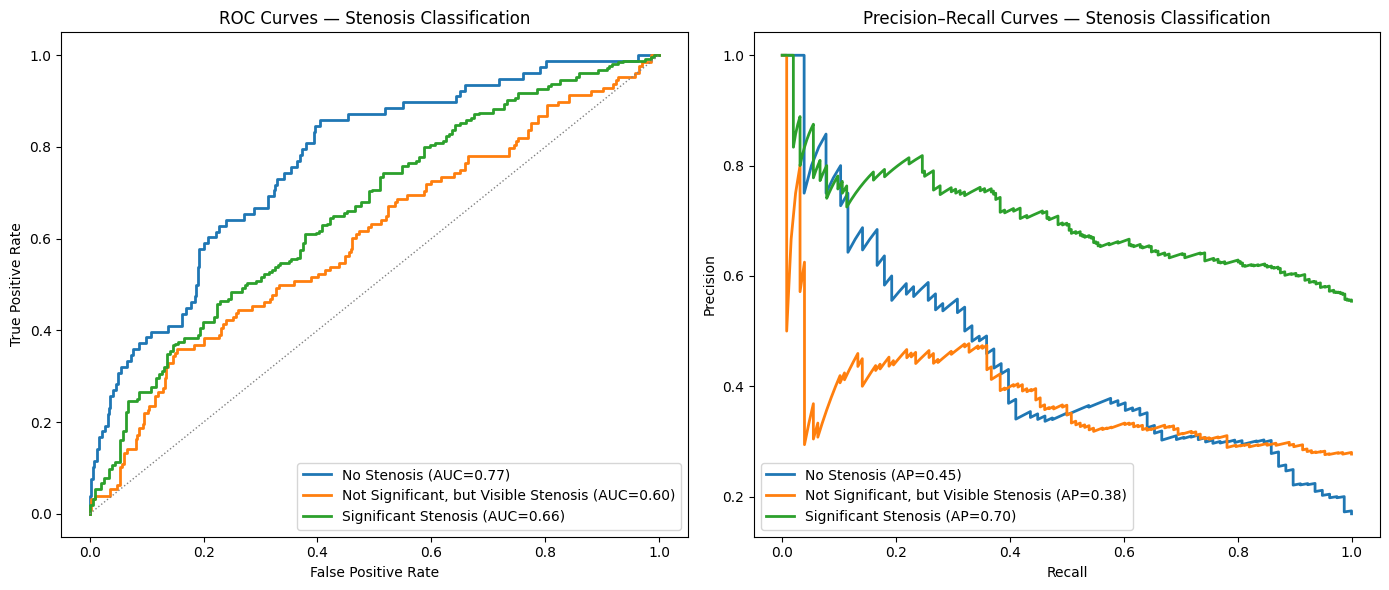

In [ ]:
# Multiclass: ROC & PR curves side-by-side with class names (no micro-average) ===
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# FIXED: Use pipeline directly with X_test_transformed (pipeline applies feature selection automatically)
# Prepare test data and model (use pipeline directly - it applies feature selection)
# Use y_proba and y_pred from Cell 6, or recompute with pipeline
y_proba = pipeline.predict_proba(X_test_transformed)  # Oder verwende y_proba aus Cell 6
y_pred = pipeline.predict(X_test_transformed)  # Oder verwende y_pred aus Cell 6
clf = pipeline.named_steps["classifier"]  # Für Klassen-Namen
classes = clf.classes_

# Define readable medical class names
class_names = {
    0: "No Stenosis",
    1: "Not Significant, but Visible Stenosis",
    2: "Significant Stenosis"
}

# Binarize labels for ROC/PR curves
Y_test_bin = label_binarize(y_test, classes=classes)

# Create a combined figure for ROC and PR
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: ROC Curves 
ax = axes[0]
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(Y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f"{class_names[cls]} (AUC={roc_auc:.2f})")

ax.plot([0, 1], [0, 1], linestyle=":", lw=1, color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Stenosis Classification")
ax.legend(loc="lower right")

# Right: Precision–Recall Curves
ax = axes[1]
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(Y_test_bin[:, i], y_proba[:, i])
    ap = average_precision_score(Y_test_bin[:, i], y_proba[:, i])
    ax.plot(recall, precision, lw=2, label=f"{class_names[cls]} (AP={ap:.2f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall Curves — Stenosis Classification")
ax.legend(loc="lower left")

plt.tight_layout()
plt.show()


# Feature Importance

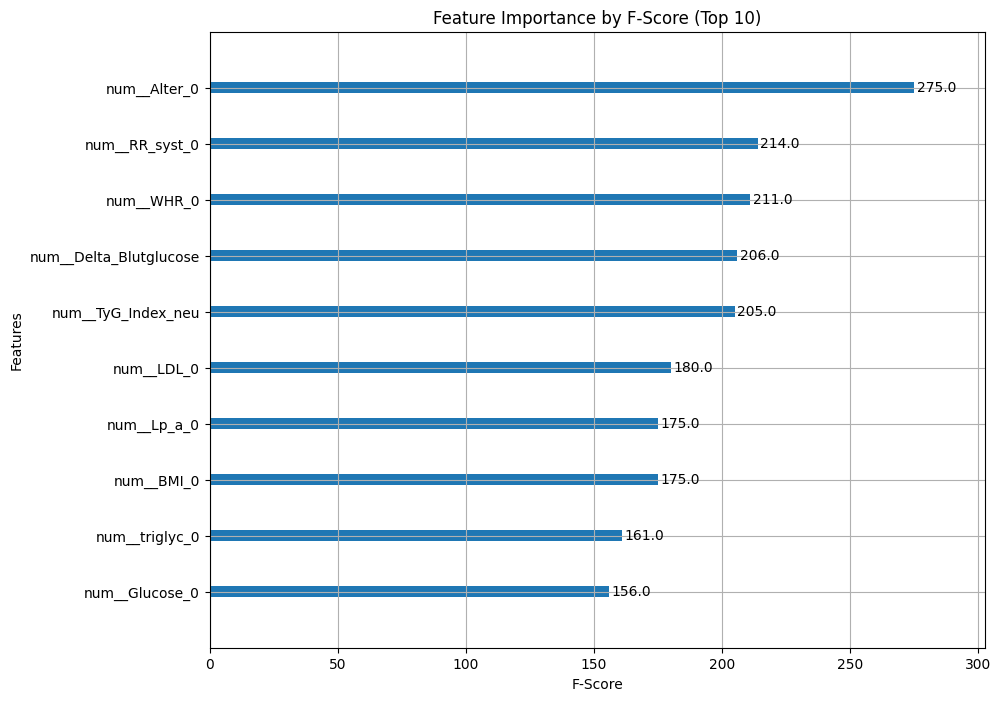

In [ ]:
# Find the top 10 important features using XGBoost's plot_importance

# 1. Get feature names from preprocessor and map to selected features
all_feature_names = temp_preprocessor.get_feature_names_out()
selected_indices = selector.get_support(indices=True)
selected_feature_names = [all_feature_names[i] for i in selected_indices]

# 2. Extract the trained XGBoost model
xgb_model = pipeline.named_steps['classifier']

# 3. Get the underlying Booster object
booster = xgb_model.get_booster()

# 4. Set the feature names on the Booster object (use selected feature names)
booster.feature_names = selected_feature_names

# 5. Plot the importance using the Booster
fig, ax = plt.subplots(1, 1, figsize=(10, 8))
plot_importance(
    booster,
    ax=ax,
    importance_type='weight',
    xlabel='F-Score',
    max_num_features=10
)
ax.set_title("Feature Importance by F-Score (Top 10)")
plt.show()

Number of features with importance == 1: 129
--- Worst 10 Features by F-Score Importance ---
               Feature  Importance
327   num__NC170OHCerl         1.0
291    num__NC70Cer2Hl         1.0
292      num__NC71Cerl         1.0
184      num__PCaeC381         1.0
294      num__NC80Cerl         1.0
295      num__NC81Cerl         1.0
297  num__NC90OHCer2Hl         1.0
298    num__NC90Cer2Hl         1.0
299      num__NC91Cerl         1.0
186      num__PCaeC384         1.0


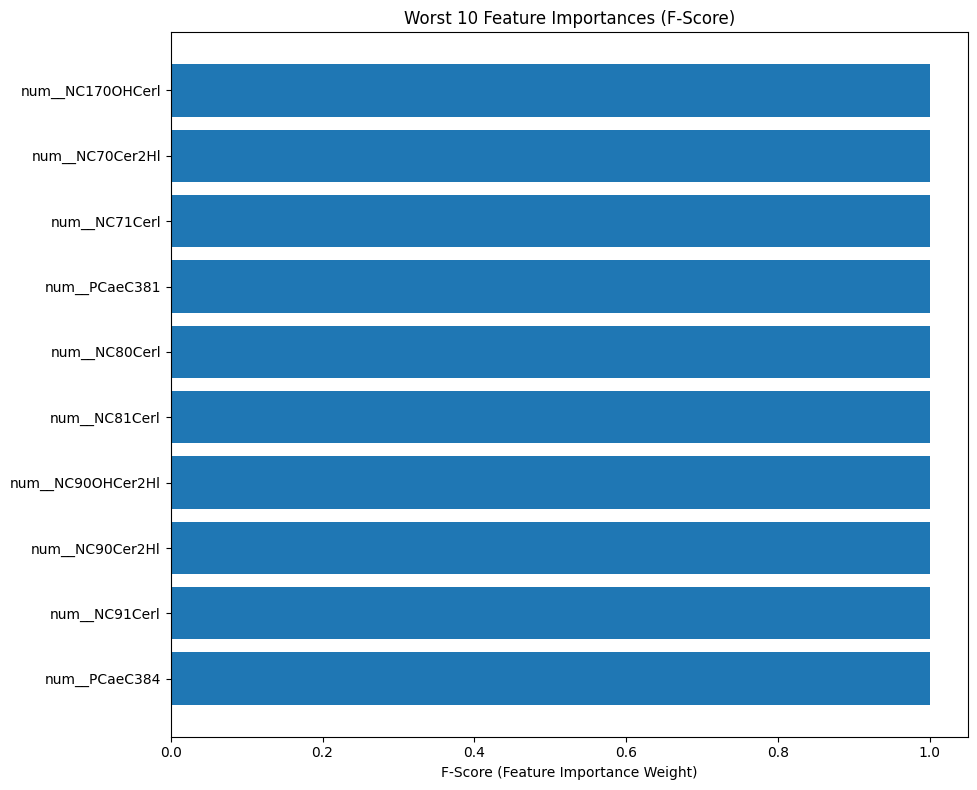

In [47]:
ig, (ax_top, ax_worst) = plt.subplots(1, 2, figsize=(18, 8)) 

# You must also define ax_top even if you don't plot on it, 
# or else you will get an index error later when you try to access ax_worst.
# Let's use a dummy plot on ax_top for now to keep the array structure intact.
ax_top.set_visible(False) # Hide the first axis if you only want to see the second one

# --- Your code snippet starts here ---
importance_dict = booster.get_score(importance_type='weight')
importance_df = pd.DataFrame(
    list(importance_dict.items()),
    columns=['Feature', 'Importance']
).sort_values(by='Importance', ascending=True)
num_features_with_importance_1 = (importance_df['Importance'] == 1).sum()
print(f"Number of features with importance == 1: {num_features_with_importance_1}")

worst_10_features = importance_df.head(10)

print("--- Worst 10 Features by F-Score Importance ---")
print(worst_10_features)

# Plot Worst 10 on the second subplot
ax_worst.barh(worst_10_features['Feature'], worst_10_features['Importance'])
ax_worst.set_title("Worst 10 Feature Importances (F-Score)")
ax_worst.set_xlabel("F-Score (Feature Importance Weight)")
ax_worst.invert_yaxis()

plt.tight_layout()
plt.show()

# Feature Selection and Model Refinement

In [48]:
# Feature Selection & Model Refinement (NaN-safe manual selection)

import pandas as pd
import numpy as np
from sklearn.metrics import balanced_accuracy_score, classification_report
from xgboost import XGBClassifier

# Fit the preprocessor before transforming (needed for OneHotEncoder)
pipeline.named_steps["preprocessor"].fit(X_train, y_train)

# Get feature names and importances from the trained XGB model
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = pipeline.named_steps["classifier"].feature_importances_

# Combine into DataFrame for easier sorting and inspection
imp_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)




# Select top 20% most important features (adjust percentage as needed)
cutoff = int(len(imp_df) * 0.325)
selected_features = imp_df["Feature"].iloc[:cutoff].tolist()

print(f"Selected top {cutoff} features out of {len(feature_names)} total.")

# Transform data (handle sparse matrix safely)
from scipy.sparse import issparse
X_train_transformed = pipeline.named_steps["preprocessor"].transform(X_train)
X_test_transformed  = pipeline.named_steps["preprocessor"].transform(X_test)
feature_names = pipeline.named_steps["preprocessor"].get_feature_names_out()

# Boolean mask for selected columns
keep_mask = np.isin(feature_names, selected_features)

# Slice directly (works for sparse or dense)
X_train_selected = X_train_transformed[:, keep_mask]
X_test_selected  = X_test_transformed[:, keep_mask]

print(f"\nOriginal features: {X_train_transformed.shape[1]}")
print(f"Selected features: {X_train_selected.shape[1]}")

# Retrain XGBoost on selected features (still handles NaNs internally)
xgb_refined = XGBClassifier(
    tree_method="hist",
    n_estimators=450,
    learning_rate=0.06,
    max_depth=3,
    subsample=0.9,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="mlogloss",
    n_jobs=-1
)

xgb_refined.fit(X_train_selected, y_train, sample_weight=sample_weights)
y_pred_refined = xgb_refined.predict(X_test_selected)

# Compare performance
print("\n--- Performance Comparison ---")
print("Baseline model:")
print(f"Balanced Accuracy: {balanced_acc:.4f}")

balanced_acc_refined = balanced_accuracy_score(y_test, y_pred_refined)
print("\nRefined model (top 20% features):")
print(f"Balanced Accuracy: {balanced_acc_refined:.4f}")

print("\nClassification Report (Refined Model):")
print(classification_report(
    y_test, y_pred_refined,
    target_names=["No Stenosis", "Non-significant stenosis", "Significant Stenosis"]
))


Fitting 5 folds for each of 288 candidates, totalling 1440 fits


Best parameters: {'classifier__colsample_bytree': 0.7, 'classifier__learning_rate': 0.04, 'classifier__max_depth': 3, 'classifier__n_estimators': 300, 'classifier__subsample': 0.8, 'feature_selection__estimator__max_depth': 4, 'feature_selection__threshold': '0.75*mean'}
CV balanced accuracy: 0.5236


NameError: name 'balanced_acc' is not defined

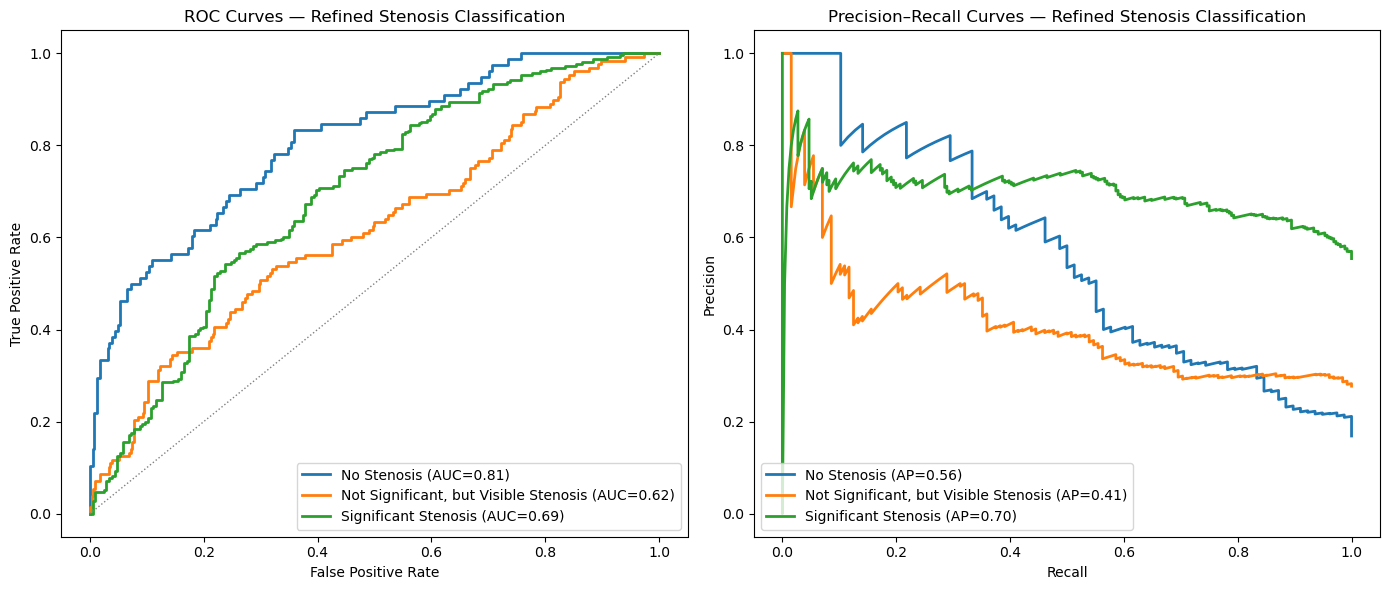

In [ ]:
# ROC & PR Curves for the Refined (Feature-Selected) Model
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score

# The refined model & its data
clf = xgb_refined
X_test_prepared = X_test_selected  # use the reduced feature set
y_proba = clf.predict_proba(X_test_prepared)
y_pred = clf.predict(X_test_prepared)
classes = clf.classes_

# Define readable medical class names
class_names = {
    0: "No Stenosis",
    1: "Not Significant, but Visible Stenosis",
    2: "Significant Stenosis"
}

# Binarize labels for ROC/PR curves
Y_test_bin = label_binarize(y_test, classes=classes)

# Create a combined figure for ROC and PR
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: ROC Curves 
ax = axes[0]
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(Y_test_bin[:, i], y_proba[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, label=f"{class_names[cls]} (AUC={roc_auc:.2f})")

ax.plot([0, 1], [0, 1], linestyle=":", lw=1, color="gray")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Refined Stenosis Classification")
ax.legend(loc="lower right")

# Right: Precision–Recall Curves
ax = axes[1]
for i, cls in enumerate(classes):
    precision, recall, _ = precision_recall_curve(Y_test_bin[:, i], y_proba[:, i])
    ap = average_precision_score(Y_test_bin[:, i], y_proba[:, i])
    ax.plot(recall, precision, lw=2, label=f"{class_names[cls]} (AP={ap:.2f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision–Recall Curves — Refined Stenosis Classification")
ax.legend(loc="lower left")

plt.tight_layout()
plt.show()
